In [8]:
from ROCRL import ROCRLLearner
from ROCRL_environment import LinearSEMGenerator, LinearUtility, ROCRLEnvironment
from metrics import *
import matplotlib.pyplot as plt
import numpy as np

In [9]:
n_latents = 5
d_obs = 10
sem = LinearSEMGenerator(n = n_latents, d = d_obs, seed = 3, latent_noise_std = 1.0)
util = LinearUtility(n = n_latents, noise_std = 1.0, theta_dist = "ones", seed = 1)
env = ROCRLEnvironment(sem = sem, utility = util)

In [10]:
intervention_type = "soft"  

for eps in [1.0, 0.75, 0.5, 0.25]:
    T0 = choose_T0_from_paper(
        n=5,
        d=5,
        epsilon_max=eps,
        delta=0.1,
        C_const=1.0,
        init_T0=50,
    )
    print(f"epsilon_max={eps:.2f} -> T0={T0}")


epsilon_max=1.00 -> T0=17
epsilon_max=0.75 -> T0=33
epsilon_max=0.50 -> T0=80
epsilon_max=0.25 -> T0=366


In [11]:
T0 = 100

learner = ROCRLLearner(
    n=n_latents,
    d=d_obs,
    intervention_type= intervention_type,
    gamma=0.5,
    epsilon_max = 0.5,
    lam=1e-3,
    seed=0,
    dim_reduction=True,
    hard_unmixing=False,
    T0=T0,
    print_debug=False
)

print("True adjacency:")
print((np.abs(sem.B) > 1e-10).astype(int).T)
print("Theta:", util.theta)


kind_of = lambda a: ("none" if len(a) == 0 else intervention_type)

actions = list(powerset_actions(n_latents))
vals = np.array([expected_utility_under_action(env, a, kind_of(a)) for a in actions])

best_idx = int(np.argmax(vals))
benchmark_action = actions[best_idx]
benchmark_reward = float(vals[best_idx])

# show top-k
k = min(5, len(actions))
top_idx = np.argsort(vals)[::-1][:k]
bottom_idx = np.argsort(vals)[:k]

print(f"Computed exact E[U] for all {len(actions)} actions (kind='{intervention_type}' for non-empty).")
print("\nTop actions:")
for rank, idx in enumerate(top_idx):
    print(f"{rank:2d}: a={fmt_action(actions[idx])}   E[U]={vals[idx]:.6f}")
print("\nBottom actions:")
for rank, idx in enumerate(bottom_idx):
    print(f"{rank:2d}: a={fmt_action(actions[idx])}   E[U]={vals[idx]:.6f}")


True adjacency:
[[0 0 1 0 1]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 0 0 0 1]
 [0 0 0 0 0]]
Theta: [1. 1. 1. 1. 1.]
Computed exact E[U] for all 6 actions (kind='soft' for non-empty).

Top actions:
 0: a={1}   E[U]=4.917022
 1: a={0}   E[U]=4.917022
 2: a=∅   E[U]=4.917022
 3: a={2}   E[U]=4.522476
 4: a={3}   E[U]=4.433572

Bottom actions:
 0: a={4}   E[U]=3.773262
 1: a={3}   E[U]=4.433572
 2: a={2}   E[U]=4.522476
 3: a=∅   E[U]=4.917022
 4: a={0}   E[U]=4.917022


Forced exploration rounds: 600
Initial cumulative regret: 202.17558941824646
First UCB round: 5462


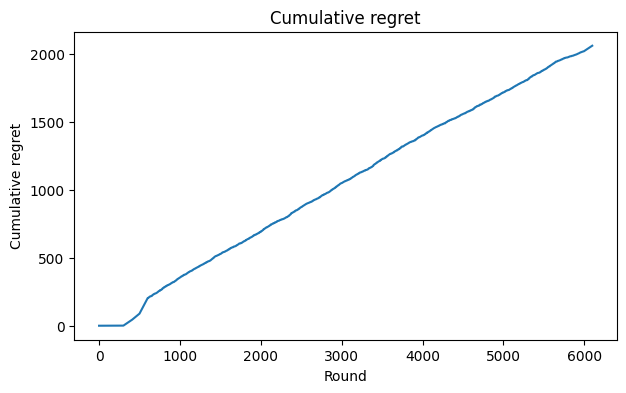

In [ ]:
T = 10000

actions_taken = []
expected_rewards = []
instant_regret = []

g = sem.G
learner.seed_initial_pools(
    env = env,
    mixing_matrix = g,
    kind = intervention_type,
    benchmark_action = benchmark_action
)

print("Forced exploration rounds:", len(learner.X_all))
print("Initial cumulative regret:", learner.cum_regret[-1])
print_every = True
ucb_count = 0


print_term = 1000
while ucb_count < 501:
    a = learner.learn()
    actions_taken.append(a)
    z_sample = sem.sample_latents(1, a)
    utility_obs = float((z_sample @ env.utility.theta).item())
    #print("utility_obs:", utility_obs)
    if env.utility.noise_std > 0:
        utility_obs += float(np.random.uniform(0.0, env.utility.noise_std))
    learner.apply_action_and_update_pools(a, z_sample, g, utility_obs)
    learner.record_regret(env, a, kind_of(a))
    
    if learner.last_decision_mode == "ucb":
        ucb_count += 1
        if ucb_count == 1:
            print("First UCB round:", t+1)
        print_term = 50
    
    if (t + 1) % print_term == 0 and print_every:
        print(f"Round {t+1}")
        print(f"Under-sampled rounds: {len([rec for rec in learner.decision_history if rec.mode == 'under_sampled'])}, UCB rounds: {len([rec for rec in learner.decision_history if rec.mode == 'ucb'])}")
        print("Cumulative regret:", learner.cum_regret[-1])
        #print(f"Threshold: {learner.f_t_val}")
        #print(f"Action counts: {learner.N_mca0}")
        #print("theta_hat:", learner.theta_hat)
        #print("  current topo:", learner.crl.topo)
        #print("  current dag:\n", learner.crl.dag_adj)

plt.figure(figsize=(7, 4))
plt.plot(learner.cum_regret)
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.title("Cumulative regret")
plt.show()

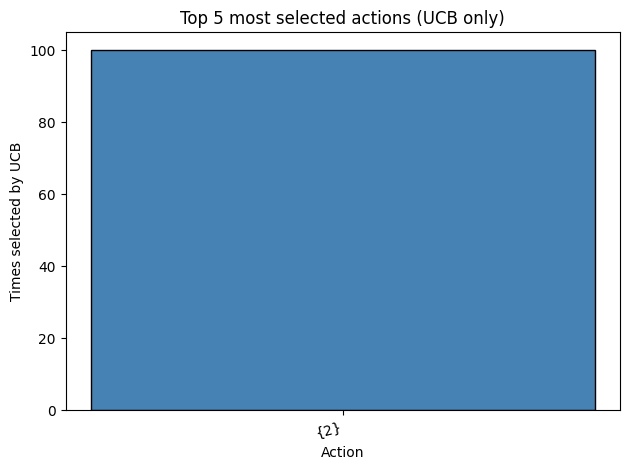

In [13]:
from collections import Counter
def action_to_label(a):
    if len(a) == 0:
        return "∅ (obs)"
    return "{" + ",".join(map(str, sorted(a))) + "}"
# Only actions that were selected by UCB (exclude under_sampled / forced exploration)
ucb_actions = [rec.action for rec in learner.decision_history if rec.mode == "ucb"]
counts = Counter(ucb_actions)
top5 = counts.most_common(5)
labels = [action_to_label(a) for a, _ in top5]
values = [c for _, c in top5]
fig, ax = plt.subplots()
ax.bar(labels, values, color="steelblue", edgecolor="black")
ax.set_xlabel("Action")
ax.set_ylabel("Times selected by UCB")
ax.set_title("Top 5 most selected actions (UCB only)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [7]:
for t in range(-5, 0):
    print("round", learner.round_history[t])
    print("action", learner.decision_history[t].action)
    print("A changed", np.max(np.abs(learner.A_hat_history[t] - learner.A_hat_history[t-1])) if t != -5 else None)
    print("nu changed", np.max(np.abs(learner.nu_hat_history[t] - learner.nu_hat_history[t-1])) if t != -5 else None)
    print()

round 9414
action frozenset({2})
A changed None
nu changed None

round 9415
action frozenset({2})
A changed 1.6057655565004936e-05
nu changed 0.007712055227859893

round 9416
action frozenset({2})
A changed 7.180247490479186e-05
nu changed 0.0002132285460845207

round 9417
action frozenset({4})
A changed 0.00012062218168162886
nu changed 0.012068622369320436

round 9418
action frozenset({2})
A changed 0.0003427376059232934
nu changed 0.011378573859684216



In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

step_size = 1

true_adj = (np.abs(sem.B) > 1e-10).astype(int).T
star_rows, star_cols = np.where(true_adj == 1)

indices = list(range(0, len(learner.A_hat_history), step_size))
if indices[-1] != len(learner.A_hat_history) - 1:
    indices.append(len(learner.A_hat_history) - 1)

all_matrices = [learner.A_hat_history[k].T for k in indices]
vmin = min(m.min() for m in all_matrices)
vmax = max(m.max() for m in all_matrices)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(all_matrices[0], aspect="auto", vmin=vmin, vmax=vmax)
stars, = ax.plot(star_cols, star_rows, marker="*", color="red", markersize=12,
                 linestyle="none", markeredgecolor="black", markeredgewidth=0.5)
ax.set_xlabel("parent index j")
ax.set_ylabel("child index i")
title = ax.set_title(f"Â  (round {learner.round_history[indices[0]]})")
fig.colorbar(im, ax=ax)
plt.close(fig)

def update(frame):
    im.set_data(all_matrices[frame])
    title.set_text(f"Â  (round {learner.round_history[indices[frame]]})")
    return im, title, stars

anim = FuncAnimation(fig, update, frames=len(indices), interval=200, blit=True)
HTML(anim.to_jshtml())